In [1]:

import pandas as pd

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.signal import butter, lfilter
from scipy.signal import find_peaks
from scipy.signal import savgol_filter, peak_prominences
from scipy.interpolate import interp1d

# Data Loading

In [2]:
# Load Head Data
file_path_head = r'C:\Users\Lindsay\Documents\alexander\Deer_project\deer_code\R4_D3_LH.csv'
columns_to_keep_head = ['TagID', 'Date', 'Time', 'X', 'Y', 'Z', 'location-lat','location-lon']
head_data_in= pd.read_csv(file_path_head,usecols=columns_to_keep_head)
head_data=head_data_in.copy()
#head_data[['location-lat', 'location-lon']]=head_data[['location-lat', 'location-lon']].ffill() # removing the nas by filling gps loection known last
#head_data[['location-lat', 'location-lon']]=head_data[['location-lat', 'location-lon']].bfill()
head_data['DateTime_Global'] = pd.to_datetime(head_data['Date'] + ' ' + head_data['Time'],format=r"%d/%m/%Y %H:%M:%S.%f")
head_data['NZ_DateTime'] = head_data['DateTime_Global'] + pd.Timedelta(hours=13)
head_data.drop(['Date', 'Time'], axis=1, inplace=True)


# Load Ear Data
file_path_ear = r'C:\Users\Lindsay\Documents\alexander\Deer_project\deer_code\R4_D3_LE.csv'
columns_to_keep_ear = ['TagID', 'Date', 'Time', 'X', 'Y', 'Z']
ear_data_in= pd.read_csv(file_path_ear, usecols=columns_to_keep_ear)
ear_data=ear_data_in.copy()
ear_data['DateTime_Global'] = pd.to_datetime(ear_data['Date'] + ' ' + ear_data['Time'],format=r"%d/%m/%Y %H:%M:%S.%f")
ear_data['NZ_DateTime'] = ear_data['DateTime_Global'] + pd.Timedelta(hours=13)
ear_data.drop(['Date', 'Time'], axis=1, inplace=True)

In [3]:
head_data_in=head_data
ear_data_in= ear_data

# Functions

In [4]:

def normalise_data(data, cols=['X', 'Y', 'Z']):
    """
    Normalise accellerometer columns in a Pandas DataFrame.

    Parameters:
    - data (pd.DataFrame): The input DataFrame.
    - cols (list): List of column names to normalize. Default is ['X', 'Y', 'Z'].

    Returns:
    - pd.DataFrame: The  normalized columns.
    """

    # Create a copy of the DataFrame to avoid modifying the original data

    # Initialize the MinMaxScaler
    scaler = StandardScaler()

    # Normalise specified columns
    normalised_data = pd.DataFrame(scaler.fit_transform(data[cols]),columns=cols)
    return normalised_data

def correct_calibration(data, calibration_row, cols=['X', 'Y', 'Z']): # calibrate ACCELLEROMETER VALS BY RMOVING THE FIRST VALUE
    cols_to_calibrate = data[cols]
    
    for column in cols_to_calibrate:
        cols_to_calibrate[column] =cols_to_calibrate[column]- calibration_row[column][0]
    return cols_to_calibrate

def make_absolute(data):
    """
    Make each column in a Pandas DataFrame the absolute value of itself.

    Parameters:
    - data (pd.DataFrame): The input DataFrame.

    Returns:
    - pd.DataFrame: The DataFrame with absolute values for each column.
    """

    # Create a copy of the DataFrame to avoid modifying the original data
    absolute_data = data.copy()

    # Take the absolute value of each column
    absolute_data = absolute_data.map(abs)
    return absolute_data


def sum_columns(data, columns_to_sum=['X', 'Y', 'Z']):
    """
    Sum together specified columns in a Pandas DataFrame.

    Parameters:
    - data (pd.DataFrame): The input DataFrame.
    - columns_to_sum (list): List of column names to sum together.

    Returns:
    - pd.Series: A Series representing the sum of the specified columns.
    """

    # Sum together specified columns
    result_series = data[columns_to_sum].sum(axis=1)

    return result_series

def get_total_absolute_accelleration(data):
    """
    Calculate the total absolute acceleration for each row in a DataFrame.

    Parameters:
    - data (pd.DataFrame): The input DataFrame containing acceleration data.

    Returns:
    - pd.Series: A Series representing the total absolute acceleration for each row.
    """
    normalised_cols = normalise_data(data)
    absolute_cols = make_absolute(normalised_cols)
    summed_cols = sum_columns(absolute_cols)
    return summed_cols

def get_calibrated_absolute_accelleration(data, calibration_row):
    """
    Calculate the total absolute acceleration for each row in a DataFrame.

    Parameters:
    - data (pd.DataFrame): The input DataFrame containing acceleration data.

    Returns:
    - pd.Series: A Series representing the total absolute acceleration for each row.
    """
    normalised_cols = correct_calibration(data,calibration_row)
    absolute_cols = make_absolute(normalised_cols)
    summed_cols = sum_columns(absolute_cols)
    return summed_cols

def high_pass_filter(data, columns, cutoff_frequency=0.1, sampling_frequency=5, order=2):
    """
    Apply a high-pass filter to a Pandas DataFrame.

    Parameters:
    - data (pd.DataFrame): The input DataFrame.
    - cutoff_frequency (float): The cutoff frequency for the high-pass filter.
    - sampling_frequency (float): The sampling frequency of the data.
    - order (int): The order of the filter.

    Returns:
    - pd.DataFrame: The DataFrame with high-pass filtered values.
    """

    # Create a copy of the DataFrame to avoid modifying the original data
    filtered_data = data.copy()

    # Calculate the Nyquist frequency
    nyquist_frequency = 0.5 * sampling_frequency

    # Design a high-pass Butterworth filter
    b, a = butter(order, cutoff_frequency / nyquist_frequency, btype='highpass',output='ba')

    # Apply the filter to each column
    columns_to_hipass= data[columns]
    for column in columns_to_hipass:
        columns_to_hipass[column] = lfilter(b, a, data[column])

    return columns_to_hipass




def find_matching_peaks(signal1, signal2, margin_of_error=2):
    peaks1, _ = find_peaks(signal1)
    peaks2, _ = find_peaks(signal2)

    matching_indices = []

    for peak1_index in peaks1:
        for peak2_index in peaks2:
            time_difference = abs(peak1_index - peak2_index)
            if time_difference <= margin_of_error:
                matching_indices.append((peak1_index, peak2_index))
                break  # Move to the next peak in the first signal

    return matching_indices




def get_consecutive_differences(points): # gets difference between one point and its next t2 and returns this smal distance matriux as pd data frame
    distances = []
    for i in range(len(points)):
        if i < len(points) - 2:
            dist_to_next_1 = points[i+1] - points[i]
            dist_to_next_2 = points[i+2] - points[i]
            distances.append([points[i], dist_to_next_1, dist_to_next_2])
        #else:
            #distances.append([points[i], None, None]) # f not 2 more exist it doesnt do anything

    # Create a DataFrame from the distances list
    df = pd.DataFrame(distances, columns=['Point', 'Distance_to_next_1', 'Distance_to_next_2'])

    return(df)



def find_3_drops(peaks_ear, peaks_head,margin_of_error = 10,drop_window_seconds = 10): # finds ,matching 3 distances from a point in 2 signals and retursn the index of the first for each signal, or None if it cant find any
    drop_window_ticks = drop_window_seconds*50
    peaks_ear = get_consecutive_differences(peaks_ear)
    peaks_head = get_consecutive_differences(peaks_head)
    # Merge the two DataFrames on the condition that the absolute difference between the distances is within the margin of error

    matched_points = []

    for _, row1 in peaks_ear.iterrows(): # add to data frame if 3 drops are matching within margin of error the distances, and all occurr within a window defined
        for _, row2 in peaks_head.iterrows():
            if (abs(row1['Distance_to_next_1'] - row2['Distance_to_next_1']) <= margin_of_error and
                    abs(row1['Distance_to_next_2'] - row2['Distance_to_next_2']) <= margin_of_error) and  abs(row1['Distance_to_next_2'] )<=drop_window_ticks:
                matched_points.append((row1['Point'], row2['Point']))

    if(len(matched_points)==0):
        return pd.DataFrame([])
    # Convert matched_points to DataFrame
    resulting_points = pd.DataFrame(matched_points, columns=['first_drop_index_ear', 'first_drop_index_head'])

    return(resulting_points)

def plot_drops(ear_data,head_data,point_ear,point_head):
    plt.plot(head_data["NZ_DateTime"], head_data["absolute_accelleration"], label='Head Data')

    # Plot NZ_DateTime against absolute_accelleration for ear data
    plt.plot(ear_data["NZ_DateTime"], ear_data["absolute_accelleration"], label='Ear Data')

    # Highlight the points in red
    plt.plot(head_data["NZ_DateTime"].iloc[point_head], head_data["absolute_accelleration"].iloc[point_head], 'ro')
    plt.plot(ear_data["NZ_DateTime"].iloc[point_ear], ear_data["absolute_accelleration"].iloc[point_ear], 'ro')

    # Add labels and legend
    plt.xlabel('NZ_DateTime')
    plt.ylabel('absolute_accelleration')

    plt.title('total Accelleration vs time with frst of 3 drops tagged.')
    plt.legend()
    plt.figure(figsize=(30, 20)) 
    # Show the plot
    plt.show()

def find_calibration_points(ear_data_window, head_data_window, calibration_row_head, calibration_row_ear, initial_prominence_level=2, plot=True):
    ear_data_window["absolute_accelleration"]=get_calibrated_absolute_accelleration(data_window_ear_end, calibration_row=calibration_row_ear)
    head_data_window["absolute_accelleration"]=get_calibrated_absolute_accelleration(data_window_head_end,calibration_row=calibration_row_head)
    
    prominence_level = initial_prominence_level  # Change this to your desired number
    decrement = 0.25
    drops = []

    while  prominence_level>= 0.5: # loops through different prominence levels starting at 2 to find the drops. down to 0.5
        peaks_ear,_ = find_peaks(ear_data_window["absolute_accelleration"], prominence=prominence_level)
        peaks_head,_ = find_peaks(head_data_window["absolute_accelleration"], prominence=prominence_level)
        drops = find_3_drops(peaks_ear,peaks_head)
        if drops.empty==False:
            break 
        prominence_level -= decrement
        if prominence_level ==0.5:
            print("Error: COultd not find 3 consecutive matching drops within data window in defined limits")
            return
    if len(drops)>1:
        print("Warning, FOund Multiple Sets of MAtching Consecutive Drops, Run again with Plot=true to check manually")
    if plot==True :
        point_ear = drops.iloc[0,0]
        point_head = drops.iloc[0,1]
        plot_drops(ear_data_window,head_data_window,point_ear,point_head)
    return(drops)
    





# Generate Absolute Columns and Prominent Peaks

In [5]:
prominence_level=2


head_data=head_data_in.copy()
head_data=head_data_in.copy()
calibration_row_head=head_data.head(1)
calibration_row_ear=ear_data.head(1)

data_window_head_end=head_data.tail(20000).reset_index()
data_window_head_end["absolute_accelleration"]=get_calibrated_absolute_accelleration(data_window_head_end,calibration_row=calibration_row_head)
data_window_ear_end=ear_data.tail(20000).reset_index()
data_window_ear_end["absolute_accelleration"]=get_calibrated_absolute_accelleration(data_window_ear_end, calibration_row=calibration_row_ear)

data_window_head_start=head_data.head(20000)
data_window_head_start["absolute_accelleration"]=get_calibrated_absolute_accelleration(data_window_head_start,calibration_row=calibration_row_head)
data_window_ear_start=ear_data.head(20000)
data_window_ear_start["absolute_accelleration"]=get_calibrated_absolute_accelleration(data_window_ear_start, calibration_row=calibration_row_ear)

peaks_head_end,_ = find_peaks(data_window_head_end["absolute_accelleration"], prominence=prominence_level)
peaks_ear_end,_ = find_peaks(data_window_ear_end["absolute_accelleration"], prominence=prominence_level)

peaks_head_start,_ = find_peaks(data_window_head_start["absolute_accelleration"], prominence=prominence_level)
peaks_ear_start,_ = find_peaks(data_window_ear_start["absolute_accelleration"], prominence=prominence_level)




proms_head_end=peak_prominences(data_window_head_end["absolute_accelleration"],peaks_head_end)[0]
data_window_head_end["prom"]=0
for i, p in enumerate(peaks_head_end):
    data_window_head_end["prom"][p]=proms_head_end[i]

proms_ear_end=peak_prominences(data_window_ear_end["absolute_accelleration"],peaks_ear_end)[0]
data_window_ear_end["prom"]=0
for i, p in enumerate(peaks_ear_end):
    data_window_ear_end["prom"][p]=proms_ear_end[i]
    

proms_head_start=peak_prominences(data_window_head_start["absolute_accelleration"],peaks_head_start)[0]
data_window_head_start["prom"]=0
for i, p in enumerate(peaks_head_start):
    data_window_head_start["prom"][p]=proms_head_start[i]
    
proms_ear_start=peak_prominences(data_window_ear_start["absolute_accelleration"],peaks_ear_start)[0]
data_window_ear_start["prom"]=0
for i, p in enumerate(peaks_ear_start):
    data_window_ear_start["prom"][p]=proms_ear_start[i]
    



C:\Users\Lindsay\AppData\Local\Temp\ipykernel_1712\1219674127.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cols_to_calibrate[column] =cols_to_calibrate[column]- calibration_row[column][0]
C:\Users\Lindsay\AppData\Local\Temp\ipykernel_1712\1219674127.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cols_to_calibrate[column] =cols_to_calibrate[column]- calibration_row[column][0]
C:\Users\Lindsay\AppData\Local\Temp\ipykernel_1712\1219674127.py:26: SettingWithCopyWarning: 
A value is trying to be se

# Use these peaks to find where the signals match

## For End

C:\Users\Lindsay\AppData\Local\Temp\ipykernel_1712\1219674127.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cols_to_calibrate[column] =cols_to_calibrate[column]- calibration_row[column][0]
C:\Users\Lindsay\AppData\Local\Temp\ipykernel_1712\1219674127.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cols_to_calibrate[column] =cols_to_calibrate[column]- calibration_row[column][0]


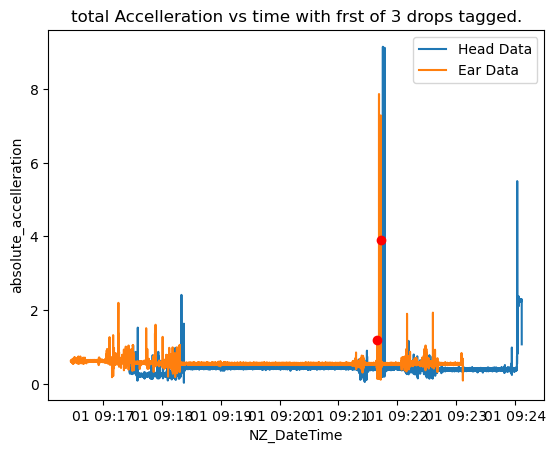

<Figure size 3000x2000 with 0 Axes>

In [6]:
end_window_beginning_index_head =head_data.shape[0]-20000 # select last 20 000
end_window_end_index_head = head_data.shape[0]
end_window_beginning_index_ear =ear_data.shape[0]-20000
end_window_end_index_ear = ear_data.shape[0]

data_window_head_end=head_data[end_window_beginning_index_head:end_window_end_index_head].reset_index()
data_window_ear_end=ear_data[end_window_beginning_index_ear:end_window_end_index_ear].reset_index()
calibration_row_head=head_data.head(1)
calibration_row_ear=ear_data.head(1)
calibration_points_end=find_calibration_points(ear_data_window=data_window_ear_end, head_data_window=data_window_head_end, calibration_row_head=calibration_row_head, calibration_row_ear=calibration_row_ear)
# Calculate distances to the next consecutive 2 points for each point

end_drop_head =calibration_points_end["first_drop_index_head"].values[0]+ end_window_beginning_index_head # return to original reference frame
end_drop_ear=calibration_points_end["first_drop_index_ear"].values[0] + end_window_beginning_index_ear

## FOr Start

In [1]:
start_window_beginning_index =0
start_window_end_index = 20000


data_window_head_start=head_data[start_window_beginning_index:start_window_end_index].reset_index()
data_window_ear_start=ear_data[start_window_beginning_index:start_window_end_index].reset_index()
calibration_row_head=head_data.head(1)
calibration_row_ear=ear_data.head(1)
calibration_points_start=find_calibration_points(ear_data_window=data_window_ear_start, head_data_window=data_window_head_start, calibration_row_head=calibration_row_head, calibration_row_ear=calibration_row_ear)
start_drop_head =calibration_points_start["first_drop_index_head"].values[0]+ start_window_beginning_index # return to original reference frame
start_drop_ear=calibration_points_start["first_drop_index_ear"].values[0] + start_window_beginning_index

NameError: name 'head_data' is not defined

# Syncing Data WIth Calibration numbers

In [8]:
# All locations in original frame of reference
start_drop_head
start_drop_ear
end_drop_ear
end_drop_head


ear_data_cut = ear_data.iloc[start_drop_ear:end_drop_ear].reset_index(drop=True)
head_data_cut = head_data.iloc[start_drop_head:end_drop_head].reset_index(drop=True)

head_n_rows=head_data_cut.shape[0]
ear_n_rows =ear_data_cut.shape[0]



In [9]:
cols = ['X', 'Y', 'Z']
interpolated_ear_data = pd.DataFrame([])
for c in cols:
    interpolated_ear_data[c] = np.interp(
        np.linspace(0, ear_n_rows - 1, head_n_rows),
        range(ear_n_rows),
        ear_data_cut[c]
    )


In [10]:
interpolated_ear_data.reset_index(drop=True, inplace=True)

In [11]:
interpolated_ear_data.columns = [f"{col}_ear" for col in interpolated_ear_data.columns]
head_data = pd.concat([head_data, interpolated_ear_data], axis=1)

In [12]:
all_accell=pd.concat([head_data_cut, interpolated_ear_data], axis="columns")

In [13]:
new_column_names_for_head = {'X': 'X_head', 'Y': 'Y_head', 'Z': 'Z_head'}
all_accell = all_accell.rename(columns=new_column_names_for_head)

In [14]:
all_accell

,TagID,X_head,Y_head,Z_head,location-lat,location-lon,DateTime_Global,NZ_DateTime,X_ear,Y_ear,Z_ear
0,AT3 rep4 29-30.11_S1,0.0125,0.9188,-0.3031,NaN,NaN,2018-11-28 18:37:41.800,2018-11-29 07:37:41.800,0.062500,-0.031200,0.937500
1,AT3 rep4 29-30.11_S1,0.0028,0.9091,-0.3225,NaN,NaN,2018-11-28 18:37:41.820,2018-11-29 07:37:41.820,0.062500,-0.031200,0.937500
2,AT3 rep4 29-30.11_S1,0.0263,0.9194,-0.3281,NaN,NaN,2018-11-28 18:37:41.840,2018-11-29 07:37:41.840,0.049712,-0.031200,0.937500
3,AT3 rep4 29-30.11_S1,0.0044,0.8950,-0.3147,NaN,NaN,2018-11-28 18:37:41.860,2018-11-29 07:37:41.860,0.046904,-0.031200,0.950582
4,AT3 rep4 29-30.11_S1,0.0275,0.9181,-0.3263,NaN,NaN,2018-11-28 18:37:41.880,2018-11-29 07:37:41.880,0.060275,-0.017825,0.953095
...,...,...,...,...,...,...,...,...,...,...,...
8952096,AT3 rep4 29-30.11_S1,-0.1544,0.8506,-0.0737,NaN,NaN,2018-11-30 20:21:43.720,2018-12-01 09:21:43.720,-0.031286,-0.031143,0.749771
8952097,AT3 rep4 29-30.11_S1,-0.1094,0.8281,-0.0744,NaN,NaN,2018-11-30 20:21:43.740,2018-12-01 09:21:43.740,-0.078143,-0.000086,0.624742
8952098,AT3 rep4 29-30.11_S1,-0.0394,0.7350,-0.0775,NaN,NaN,2018-11-30 20:21:43.760,2018-12-01 09:21:43.760,-0.109371,-0.062600,0.437371
8952099,AT3 rep4 29-30.11_S1,-0.0156,0.4288,-0.2037,NaN,NaN,2018-11-30 20:21:43.780,2018-12-01 09:21:43.780,-0.078028,-0.172072,0.296743


In [15]:
# all_accell.to_hdf('R3D1_Combined.h5', key='df', mode='w')

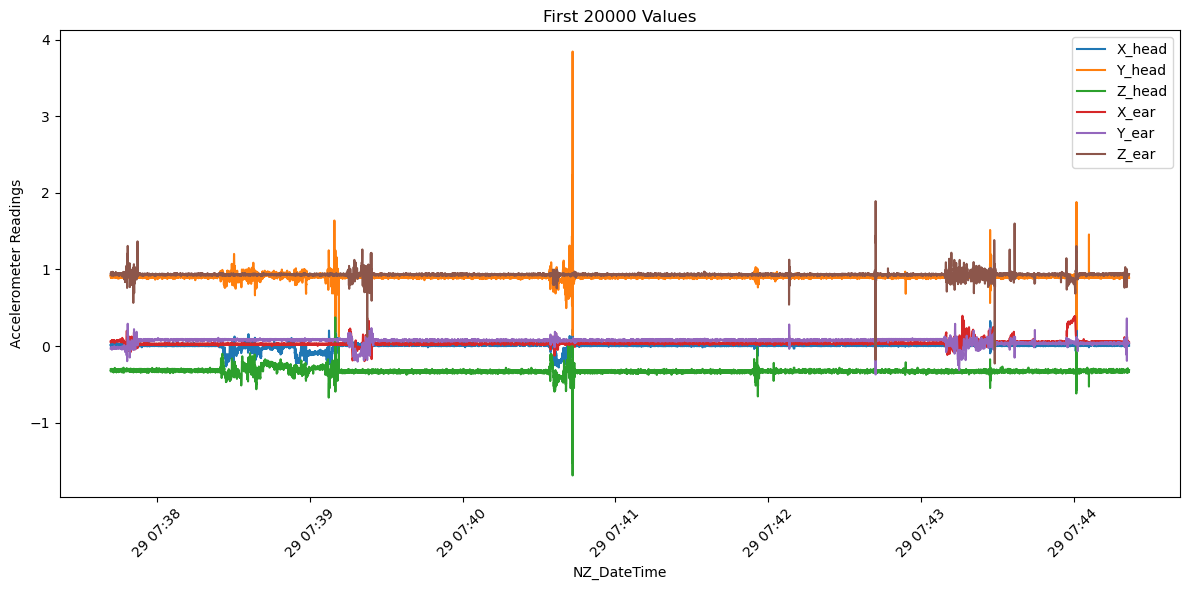

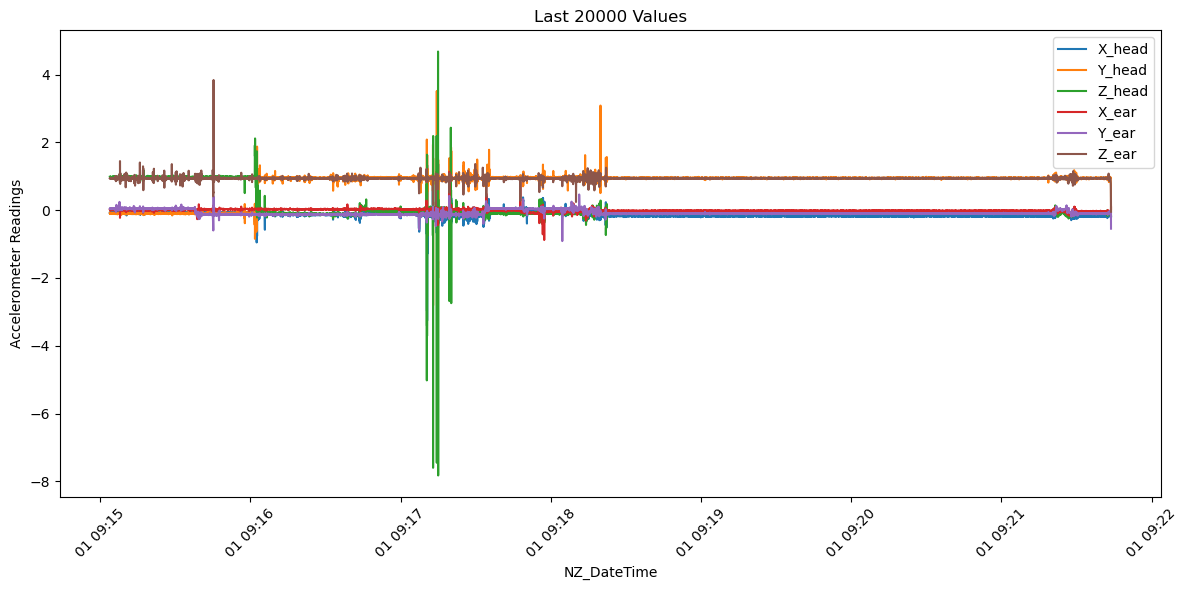

In [16]:

# Assuming all_accell is your DataFrame

# Plotting the first 20000 values
plt.figure(figsize=(12, 6))
plt.plot(all_accell['NZ_DateTime'].iloc[:20000], all_accell['X_head'].iloc[:20000], label='X_head')
plt.plot(all_accell['NZ_DateTime'].iloc[:20000], all_accell['Y_head'].iloc[:20000], label='Y_head')
plt.plot(all_accell['NZ_DateTime'].iloc[:20000], all_accell['Z_head'].iloc[:20000], label='Z_head')
plt.plot(all_accell['NZ_DateTime'].iloc[:20000], all_accell['X_ear'].iloc[:20000], label='X_ear')
plt.plot(all_accell['NZ_DateTime'].iloc[:20000], all_accell['Y_ear'].iloc[:20000], label='Y_ear')
plt.plot(all_accell['NZ_DateTime'].iloc[:20000], all_accell['Z_ear'].iloc[:20000], label='Z_ear')
plt.xlabel('NZ_DateTime')
plt.ylabel('Accelerometer Readings')
plt.title('First 20000 Values')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plotting the last 20000 values
plt.figure(figsize=(12, 6))
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], all_accell['X_head'].iloc[-20000:], label='X_head')
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], all_accell['Y_head'].iloc[-20000:], label='Y_head')
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], all_accell['Z_head'].iloc[-20000:], label='Z_head')
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], all_accell['X_ear'].iloc[-20000:], label='X_ear')
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], all_accell['Y_ear'].iloc[-20000:], label='Y_ear')
plt.plot(all_accell['NZ_DateTime'].iloc[-20000:], all_accell['Z_ear'].iloc[-20000:], label='Z_ear')
plt.xlabel('NZ_DateTime')
plt.ylabel('Accelerometer Readings')
plt.title('Last 20000 Values')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




# Calculate Lag at which start and end SIgnals are most correlated

In [17]:
cross_corr_end = np.correlate(data_window_head_end['prom'].values, data_window_ear_end['prom'].values, mode='full')
cross_corr_end = np.correlate(data_window_head_end['prom'].values, data_window_ear_end['prom'].values, mode='full')
# Find the lag corresponding to the maximum correlation
lag_end = np.argmax(cross_corr_end) - len(data_window_head_end['prom']) + 1

print(lag_end)

KeyError: 'prom'

In [ ]:
print(data_window_head_end)

         index                 TagID       X       Y       Z  location-lat  \
0      8961901  AT1 Rep3 22-24.11_S1  0.1094 -0.2028  0.9847     -38.11411   
1      8961902  AT1 Rep3 22-24.11_S1  0.1094 -0.1731  0.9844     -38.11411   
2      8961903  AT1 Rep3 22-24.11_S1  0.1094 -0.1866  0.9844     -38.11411   
3      8961904  AT1 Rep3 22-24.11_S1  0.0950 -0.1731  0.9988     -38.11411   
4      8961905  AT1 Rep3 22-24.11_S1  0.0938 -0.2000  1.0000     -38.11411   
...        ...                   ...     ...     ...     ...           ...   
19995  8981896  AT1 Rep3 22-24.11_S1  0.0938  0.0781  1.0000     -38.11413   
19996  8981897  AT1 Rep3 22-24.11_S1  0.0781  0.0938  1.0078     -38.11413   
19997  8981898  AT1 Rep3 22-24.11_S1  0.0625  0.1094  1.0156     -38.11413   
19998  8981899  AT1 Rep3 22-24.11_S1  0.0625  0.1094  1.0156     -38.11413   
19999  8981900  AT1 Rep3 22-24.11_S1  0.0000  0.0000  0.0000     -38.11413   

       location-lon         DateTime_Global             NZ_Date

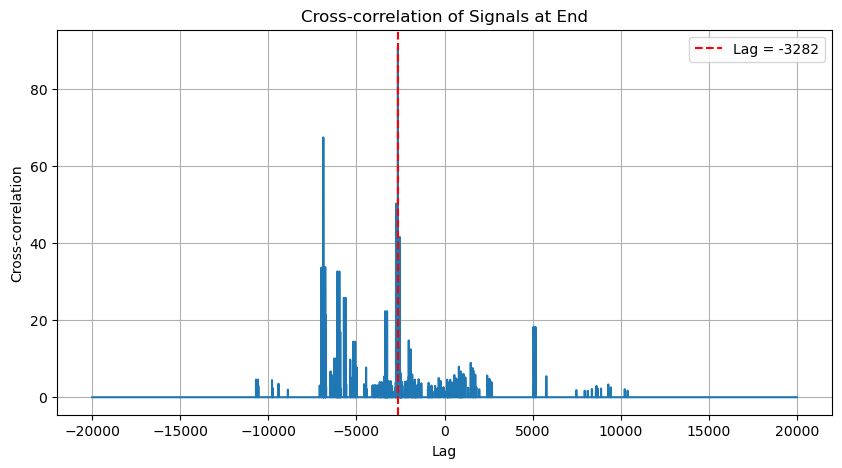

Maximum correlation: 90.77301132000002
Lag (in samples): -3282
Signals are likely similar with a phase shift.


In [ ]:

# Assuming your signals are stored in pandas DataFrames df1 and df2
signal1 = data_window_head_end['prom'].values
signal2 = data_window_ear_end['prom'].values
threshold=10
# Compute cross-correlation
cross_corr = np.correlate(signal1, signal2, mode='full')

# Find the lag corresponding to the maximum correlation
lag_start = np.argmax(cross_corr) - len(signal1) + 1

# Plot cross-correlation
plt.figure(figsize=(10, 5))
plt.plot(np.arange(-len(signal1) + 1, len(signal2)), cross_corr)
plt.axvline(lag_start, color='r', linestyle='--', label=f'Lag = {lag}')
plt.xlabel('Lag')
plt.ylabel('Cross-correlation')
plt.title('Cross-correlation of Signals at End')
plt.legend()
plt.grid(True)
plt.show()

# Check if the maximum correlation is close to 1
max_corr = np.max(cross_corr)
if max_corr > threshold:
    print("Maximum correlation:", max_corr)
    print("Lag (in samples):", lag)
    print("Signals are likely similar with a phase shift.")
else:
    print("Signals are not similar.")

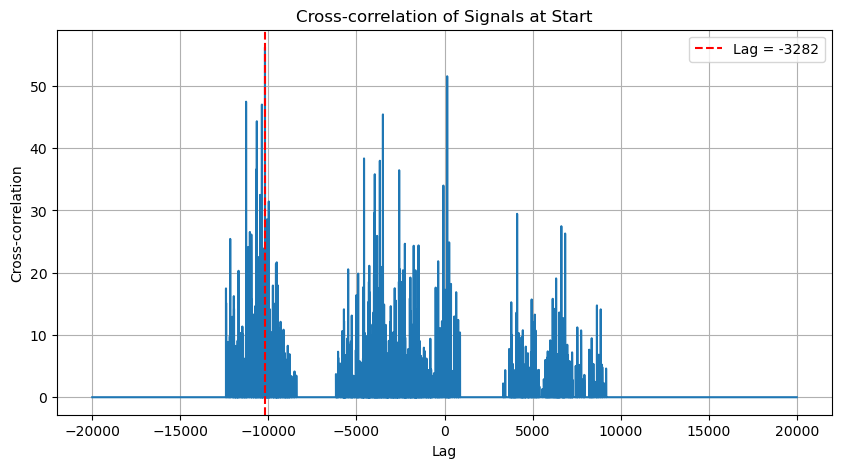

Maximum correlation: 56.201960699999994
Lag (in samples): -3282
Signals are likely similar with a phase shift.


In [ ]:

# Assuming your signals are stored in pandas DataFrames df1 and df2
signal1 = data_window_head_start['prom'].values
signal2 = data_window_ear_start['prom'].values
threshold=10
# Compute cross-correlation
cross_corr = np.correlate(signal1, signal2, mode='full')

# Find the lag corresponding to the maximum correlation
lag_end = np.argmax(cross_corr) - len(signal1) + 1

# Plot cross-correlation
plt.figure(figsize=(10, 5))
plt.plot(np.arange(-len(signal1) + 1, len(signal2)), cross_corr)
plt.axvline(lag_end, color='r', linestyle='--', label=f'Lag = {lag}')
plt.xlabel('Lag')
plt.ylabel('Cross-correlation')
plt.title('Cross-correlation of Signals at Start')
plt.legend()
plt.grid(True)
plt.show()

# Check if the maximum correlation is close to 1
max_corr = np.max(cross_corr)
if max_corr > threshold:
    print("Maximum correlation:", max_corr)
    print("Lag (in samples):", lag)
    print("Signals are likely similar with a phase shift.")
else:
    print("Signals are not similar.")

# Aligning Signals

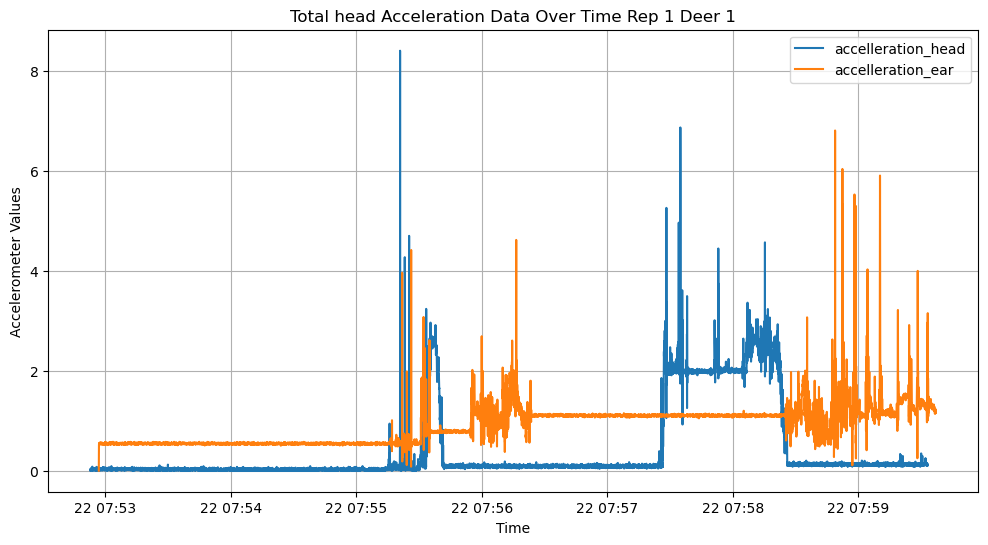

In [ ]:
# Downsample the data to a manageable size, for example, every 1000th data point
df = data_window_head_start
df1= data_window_ear_start
# Set up the plot
plt.figure(figsize=(12, 6))

# Plot X, Y, and Z over time
plt.plot(df['NZ_DateTime'], df['absolute_accelleration'], label='accelleration_head')
plt.plot(df1['NZ_DateTime'], df1['absolute_accelleration'], label='accelleration_ear')
# Customize the plot
plt.title('Total head Acceleration Data Over Time Rep 1 Deer 1')
plt.xlabel('Time')
plt.ylabel('Accelerometer Values')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

In [ ]:
import pandas as pd

def find_matching_peak_sets(peaks1, peaks2, max_spacing=(7*50)):
    matching_sets = []

    for i in range(len(peaks1) - 2):
        for j in range(len(peaks2) - 2):
            spacing1 = peaks1[i+1] - peaks1[i]
            spacing2 = peaks2[j+1] - peaks2[j]
            if np.abs(spacing1 - spacing2) <= max_spacing:
                if peaks1[i+2] - peaks1[i+1] == spacing1 and peaks2[j+2] - peaks2[j+1] == spacing2:
                    matching_sets.append((peaks1[i], peaks1[i+1], peaks1[i+2], peaks2[j], peaks2[j+1], peaks2[j+2]))
    
    return matching_sets

find_matching_peak_sets(peaks_ear_end, peaks_head_end)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "c:\Users\Lindsay\anaconda3\envs\deer_project_2\Lib\site-packages\IPython\core\interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\Lindsay\AppData\Local\Temp\ipykernel_20836\1530273085.py", line 16, in <module>
    find_matching_peak_sets(peaks_ear_end, peaks_head_end)
  File "C:\Users\Lindsay\AppData\Local\Temp\ipykernel_20836\1530273085.py", line None, in find_matching_peak_sets
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "c:\Users\Lindsay\anaconda3\envs\deer_project_2\Lib\site-packages\IPython\core\interactiveshell.py", line 2144, in showtraceback
    stb = self.InteractiveTB.structured_traceback(
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lindsay\anaconda3\envs\deer_project_2\Lib\site-packages\IPython\core\ultratb.py", line 1435, in structured_traceback
    return Form

In [ ]:
len(peaks_ear_end)
len(peaks_head_end)
len(peaks_ear_start)
len(peaks_head_start)

27